# Approach 7: Physics-Informed Feature Extraction

EP-PINN with an EAND-ARN style encoder. Estimates global Aliev-Panfilov parameters: D (diffusion), a (excitability), and a recovery-scale parameter mapped from b to k_rep. Heads are written as (D, a, b) in the code for brevity.

Pipeline:
1. Encoder: 1D adaptive residual blocks plus explicit numerical temporal derivatives and inter-lead second differences.
2. EP parameters: positive scalars per sample via softplus with fixed scales.
3. Weak physics loss L_EP: finite-difference residual of the AP u-equation on an ECG-derived surrogate u(t).
4. Downstream classifier: MLP on the three EP features.

The physics term is a consistency regulariser, not a full inverse ECGI solve. The inter-lead Laplacian treats the 12 leads as an ordered sequence rather than a geometrically correct grid.

Prerequisite: run chagas_resnet_classifier.ipynb to build preprocessed_cache_brazil.h5.

---
## 1. Environment & imports

In [1]:
import math
import logging
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.stats import mannwhitneyu
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import StratifiedShuffleSplit
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader

sns.set_context("notebook")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s", datefmt="%H:%M:%S")
logger = logging.getLogger("ep_pinn")

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"PyTorch {torch.__version__} | device = {device}")

/Users/jwasieleski/Prywatne/jul/workspace/magisterka/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch 2.10.0 | device = mps


## 2. Configuration

In [2]:
CFG = {
    "preprocessed_cache": "preprocessed_cache_brazil.h5",
    "val_fraction": 0.15,
    "test_fraction": 0.15,
    "random_seed": 42,
    "target_fs": 500,
    "target_duration_s": 10,
    "in_channels": 12,
    "base_ch": 64,
    "num_adap_blocks": 4,
    "kernel_size": 15,
    "dropout": 0.2,
    "D_scale": 20.0,
    "a_scale": 0.25,
    "b_scale": 12.0,
    "lambda_ep": 0.05,
    "epochs": 40,
    "batch_size": 16,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "warmup_epochs": 2,
    "grad_clip": 1.0,
    "num_workers": 0,
    "focal_alpha": 0.75,
    "focal_gamma": 2.0,
}

seq_len = CFG["target_fs"] * CFG["target_duration_s"]
dt = 1.0 / CFG["target_fs"]
print(f"seq_len={seq_len}, dt={dt}")

seq_len=5000, dt=0.002


---
## 3. Load cache & splits (same as ResNet / diffusion notebooks)

In [3]:
cache_file = CFG["preprocessed_cache"]
assert Path(cache_file).exists(), f"Missing {cache_file} - run chagas_resnet_classifier.ipynb first."

with h5py.File(cache_file, "r") as f:
    n_total = f["labels"].shape[0]
    all_labels = f["labels"][:]
    sig_shape = f["signals"].shape
    assert sig_shape[1:] == (12, seq_len), (
        f"Signal shape mismatch: expected (n, 12, {seq_len}), got {sig_shape}. "
        "Re-run chagas_resnet_classifier.ipynb with matching CFG."
    )
    print(f"Samples: {n_total:,} | Chagas+ {100*all_labels.mean():.1f}%")

all_indices = np.arange(n_total)

sss_test = StratifiedShuffleSplit(
    n_splits=1, test_size=CFG["test_fraction"], random_state=CFG["random_seed"]
)
dev_indices, test_indices = next(sss_test.split(all_indices, all_labels))

val_fraction_of_dev = CFG["val_fraction"] / (1.0 - CFG["test_fraction"])
sss_val = StratifiedShuffleSplit(
    n_splits=1, test_size=val_fraction_of_dev, random_state=CFG["random_seed"]
)
train_rel, val_rel = next(sss_val.split(dev_indices, all_labels[dev_indices]))
train_indices = dev_indices[train_rel]
val_indices = dev_indices[val_rel]

print(f"train={len(train_indices):,} val={len(val_indices):,} test={len(test_indices):,}")
print(
    f"Chagas+ - train={100*all_labels[train_indices].mean():.1f}%  "
    f"val={100*all_labels[val_indices].mean():.1f}%  "
    f"test={100*all_labels[test_indices].mean():.1f}%"
)

Samples: 49,152 | Chagas+ 16.7%
train=34,406 val=7,373 test=7,373
Chagas+ — train=16.7%  val=16.7%  test=16.7%


In [4]:
class CachedChagasDataset(Dataset):
    def __init__(self, cache_path, indices):
        self.cache_path = cache_path
        self.indices = np.sort(indices)
        self._file = None
        with h5py.File(cache_path, "r") as f:
            self.labels = f["labels"][self.indices]

    def __len__(self):
        return len(self.indices)

    def _f(self):
        if self._file is None:
            self._file = h5py.File(self.cache_path, "r")
        return self._file

    def __getitem__(self, idx):
        f = self._f()
        ri = self.indices[idx]
        x = torch.from_numpy(f["signals"][ri]).float()
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

    def __del__(self):
        if self._file is not None:
            try:
                self._file.close()
            except Exception:
                pass

pin = device.type == "cuda"
train_ds = CachedChagasDataset(cache_file, train_indices)
val_ds = CachedChagasDataset(cache_file, val_indices)
test_ds = CachedChagasDataset(cache_file, test_indices)

train_loader = DataLoader(
    train_ds,
    batch_size=CFG["batch_size"],
    shuffle=True,
    num_workers=CFG["num_workers"],
    pin_memory=pin,
    drop_last=True,
)
val_loader = DataLoader(val_ds, batch_size=CFG["batch_size"], shuffle=False, num_workers=CFG["num_workers"], pin_memory=pin)
test_loader = DataLoader(test_ds, batch_size=CFG["batch_size"], shuffle=False, num_workers=CFG["num_workers"], pin_memory=pin)

print(f"Train batches: {len(train_loader)}")

Train batches: 2150


---
## 4. Metrics & Focal loss

In [5]:
@dataclass
class EvalResult:
    auroc: float
    auprc: float
    challenge_score: float
    f1: float
    sens: float
    spec: float

def calculate_tpr_at_capacity(y_true, y_prob, capacity_ratio=0.05):
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob, dtype=float)
    n_positives = np.sum(y_true)
    if n_positives == 0: return 0.0
    M = int(np.floor(len(y_true) * capacity_ratio))
    if M == 0: return 0.0
    sorted_indices = np.argsort(y_prob)[::-1]
    top_m_indices = sorted_indices[:M]
    tp_in_top_m = np.sum(y_true[top_m_indices])
    threshold_prob = y_prob[sorted_indices[M-1]]
    patients_at_threshold = np.where(y_prob == threshold_prob)[0]
    included_at_threshold = np.sum(y_prob[top_m_indices] == threshold_prob)
    if len(patients_at_threshold) > included_at_threshold and included_at_threshold > 0:
        tp_above_threshold = np.sum(y_true[y_prob > threshold_prob])
        positives_at_threshold = np.sum(y_true[patients_at_threshold])
        expected_tp_from_ties = positives_at_threshold * (included_at_threshold / len(patients_at_threshold))
        expected_tp = tp_above_threshold + expected_tp_from_ties
        tpr = expected_tp / n_positives
    else:
        tpr = tp_in_top_m / n_positives
    return float(tpr)

def compute_metrics(y_true, y_prob, thr=0.5):
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob, dtype=float)
    if len(np.unique(y_true)) < 2:
        return EvalResult(float("nan"), float("nan"), float("nan"), 0.0, 0.0, 0.0)
    auroc = roc_auc_score(y_true, y_prob)
    auprc = average_precision_score(y_true, y_prob)
    cs = calculate_tpr_at_capacity(y_true, y_prob, 0.05)
    yp = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, yp, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    f1 = f1_score(y_true, yp, zero_division=0)
    return EvalResult(auroc, auprc, cs, f1, sens, spec)

def best_f1_threshold(y_true, y_prob):
    best_f1, best_t = 0.0, 0.5
    for t in np.linspace(0.05, 0.95, 191):
        f1 = compute_metrics(y_true, y_prob, t).f1
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return float(best_t)

def bootstrap_ci(y_true, y_prob, metric_fn, n_boot=1000, ci=0.95, seed=42):
    rng = np.random.RandomState(seed)
    scores = []
    for _ in range(n_boot):
        idx = rng.choice(len(y_true), len(y_true), replace=True)
        yt, yp = y_true[idx], y_prob[idx]
        if len(np.unique(yt)) < 2:
            continue
        scores.append(metric_fn(yt, yp))
    lo = np.percentile(scores, 100 * (1 - ci) / 2)
    hi = np.percentile(scores, 100 * (1 + ci) / 2)
    return float(np.mean(scores)), float(lo), float(hi)

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        targets = targets.float()
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        pt = torch.exp(-bce)
        at = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        return (at * (1 - pt).pow(self.gamma) * bce).mean()

## 5. Encoder and EP-PINN

- AdapResBlock1D: residual branch scaled by a learnable alpha, initialised at 0 so the block starts near identity.
- Explicit derivatives: temporal gradient and inter-lead second differences (circular) at each timepoint.
- Heads: (D, a, b) with b standing in for k_rep, plus an auxiliary v for the recovery term in the u-residual.

(D, a, b) are learned discriminative features constrained to interpretable ranges, not parameters from an inverse solve.

In [6]:
class AdapResBlock1D(nn.Module):
    """Adaptive residual block (ARN): y = x + alpha * F(x), alpha init 0."""

    def __init__(self, ch, kernel_size=15, dropout=0.2):
        super().__init__()
        pad = kernel_size // 2
        self.conv = nn.Sequential(
            nn.Conv1d(ch, ch, kernel_size, padding=pad, bias=False),
            nn.GroupNorm(8, ch),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Conv1d(ch, ch, kernel_size, padding=pad, bias=False),
            nn.GroupNorm(8, ch),
        )
        self.alpha = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        return x + self.alpha * self.conv(x)

class EPPINNChagas(nn.Module):
    """
    EP-PINN: ECG -> (D, a, b) + classifier logits from EP features only.
    b maps to k_rep (repolarization / APD-related scale in AP dynamics).
    """

    def __init__(self, cfg):
        super().__init__()
        c = cfg["base_ch"]
        self.stem = nn.Sequential(
            nn.Conv1d(cfg["in_channels"], c, kernel_size=cfg["kernel_size"], padding=cfg["kernel_size"] // 2, bias=False),
            nn.GroupNorm(8, c),
            nn.GELU(),
        )
        self.blocks = nn.ModuleList(
            [AdapResBlock1D(c, cfg["kernel_size"], cfg["dropout"]) for _ in range(cfg["num_adap_blocks"])]
        )
        self.down = nn.Conv1d(c, c, kernel_size=4, stride=2, padding=1, bias=False)
        self.proj = nn.Sequential(nn.GroupNorm(8, c), nn.GELU())
        self.deriv_mlp = nn.Sequential(nn.Linear(4, 32), nn.GELU(), nn.Linear(32, 32))
        ctx = c + 32
        self.ep_head = nn.Linear(ctx, 4)
        self.clf = nn.Sequential(
            nn.Linear(3, 32),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
        )
        self.D_scale = cfg["D_scale"]
        self.a_scale = cfg["a_scale"]
        self.b_scale = cfg["b_scale"]

    def encode_context(self, x):
        h = self.stem(x)
        for blk in self.blocks:
            h = blk(h)
        h = self.down(h)
        h = self.proj(h)
        gap = h.mean(dim=-1)
        dtd = (x[..., 1:] - x[..., :-1]).abs().mean(dim=(1, 2), keepdim=False)
        dtd2 = (x[..., 2:] - 2 * x[..., 1:-1] + x[..., :-2]).abs().mean(dim=(1, 2), keepdim=False)
        xl = torch.cat([x[:, -1:, :], x, x[:, :1, :]], dim=1)
        lap_l = (xl[:, 2:, :] - 2 * xl[:, 1:-1, :] + xl[:, :-2, :]).abs().mean(dim=(1, 2), keepdim=False)
        feat = torch.stack([dtd, dtd2, lap_l, x.std(dim=(1, 2))], dim=-1)
        feat = self.deriv_mlp(feat)
        ctx_vec = torch.cat([gap, feat], dim=-1)
        return ctx_vec

    def forward(self, x, return_ep=False):
        ctx = self.encode_context(x)
        raw = self.ep_head(ctx)
        D = F.softplus(raw[:, 0:1]) * (self.D_scale / 2.0) + 1e-4
        a = torch.sigmoid(raw[:, 1:2]) * self.a_scale + 1e-4
        b_rep = F.softplus(raw[:, 2:3]) * (self.b_scale / 4.0) + 0.5
        v_aux = torch.tanh(raw[:, 3:4]) * 0.5
        ep = torch.cat([D, a, b_rep], dim=-1)
        logits = self.clf(ep).squeeze(-1)
        if return_ep:
            return logits, ep, v_aux
        return logits

def aliev_panfilov_u_residual(ecg, D, a, k_rep, v_scalar):
    """
    Weak AP consistency residual on ECG surrogate u(t) normalised to (0,1).
    Standard AP u-equation (Aliev & Panfilov 1996):
      du/dt = D∇²u + k·u·(u−a)·(1−u) − u·v
    The cubic term is excitatory (positive) for u ∈ (a, 1).

    Scale notes:
    - du_dt and lap_m are each normalised to [-1,1] per sample (scale is
      otherwise ~250-500 /s vs O(10) for RHS without normalisation).
    - lap is computed from raw ecg (unnormalised leads); um uses normalised u.
      Both are re-scaled to [-1,1], so the inconsistency does not break the
      loss numerically but means the AP equation is dimensionally approximate.

    Gradient note (ecg is typically passed as x.detach() from the training loop):
    - Detaching ecg blocks gradient through du_dt_raw and lap_m only.
    - D, a, k_rep, v_scalar still carry computation graphs back through
      ep_head → encode_context, so the encoder IS updated by L_ep.
    """
    B, L, T = ecg.shape
    u = ecg.mean(dim=1)
    u_min = u.min(dim=-1, keepdim=True).values
    u_max = u.max(dim=-1, keepdim=True).values
    u = (u - u_min) / (u_max - u_min + 1e-6)
    u = u.clamp(1e-3, 1 - 1e-3)
    du_dt_raw = (u[:, 2:] - u[:, :-2]) / 2.0
    du_dt = du_dt_raw / (du_dt_raw.abs().amax(dim=-1, keepdim=True).clamp_min(1e-6))
    um = u[:, 1:-1]
    xl = torch.cat([ecg[:, -1:, :], ecg, ecg[:, :1, :]], dim=1)
    lap = xl[:, 2:, :] - 2 * xl[:, 1:-1, :] + xl[:, :-2, :]
    lap_m = lap.mean(dim=1)[:, 1:-1]
    lap_m = lap_m / (lap_m.abs().amax(dim=-1, keepdim=True).clamp_min(1e-6))
    rhs = D * lap_m + k_rep * um * (1.0 - um) * (um - a) - um * v_scalar
    r = du_dt - rhs
    return r.pow(2).mean()

torch.manual_seed(CFG["random_seed"])
model = EPPINNChagas(CFG).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"EP-PINN parameters: {n_params:,}")

EP-PINN parameters: 522,473


### Limitations

The EP residual is an AP-inspired regulariser, not a strict PINN residual.

1. Signal mismatch. The AP model describes transmembrane voltage in tissue; the mean of 12 surface leads is only a heuristic proxy.
2. Scalar recovery. v is predicted as one global scalar per sample, dropping all spatiotemporal recovery dynamics.
3. Lead Laplacian. Second differences across 12 leads treat them as a circular 1D grid, which they are not. lap_m is built from raw ECG while um uses normalised u; per-sample renormalisation to [-1, 1] hides the scale mismatch but does not fix the dimensional issue.
4. Learned (D, a, b) are discriminative features, not inversely estimated AP parameters.
5. Gradient flow. Detaching x blocks gradients through du_dt_raw and lap_m only. D, a, k_rep, v_aux still propagate back through ep_head into the encoder, so L_ep updates the backbone too.

Section 8 trains the same architecture with lambda_ep = 0 to measure what the AP term actually buys.

---
## 6. Training

epoch 1/40: 100%|██████████| 2150/2150 [03:35<00:00,  9.98it/s, cls=0.0508, ep=0.0260, loss=0.0521]
00:28:57 [INFO] Epoch 1 | train loss 0.0521 (cls 0.0508, ep 0.0260) | val AUROC 0.7686 AUPRC 0.4412 CS 0.1945
00:28:57 [INFO]   ↳ New best — checkpoint saved (val AUROC=0.7686)
epoch 2/40: 100%|██████████| 2150/2150 [04:12<00:00,  8.50it/s, cls=0.0471, ep=0.0255, loss=0.0484]
00:33:30 [INFO] Epoch 2 | train loss 0.0484 (cls 0.0471, ep 0.0255) | val AUROC 0.7771 AUPRC 0.4621 CS 0.2050
00:33:30 [INFO]   ↳ New best — checkpoint saved (val AUROC=0.7771)
epoch 3/40: 100%|██████████| 2150/2150 [03:42<00:00,  9.67it/s, cls=0.0458, ep=0.0252, loss=0.0470]
00:37:32 [INFO] Epoch 3 | train loss 0.0470 (cls 0.0458, ep 0.0252) | val AUROC 0.7842 AUPRC 0.4697 CS 0.2018
00:37:32 [INFO]   ↳ New best — checkpoint saved (val AUROC=0.7842)
epoch 4/40: 100%|██████████| 2150/2150 [03:34<00:00, 10.00it/s, cls=0.0453, ep=0.0250, loss=0.0465]
00:41:26 [INFO] Epoch 4 | train loss 0.0465 (cls 0.0453, ep 0.0250) |

Restored best val AUROC = 0.8083


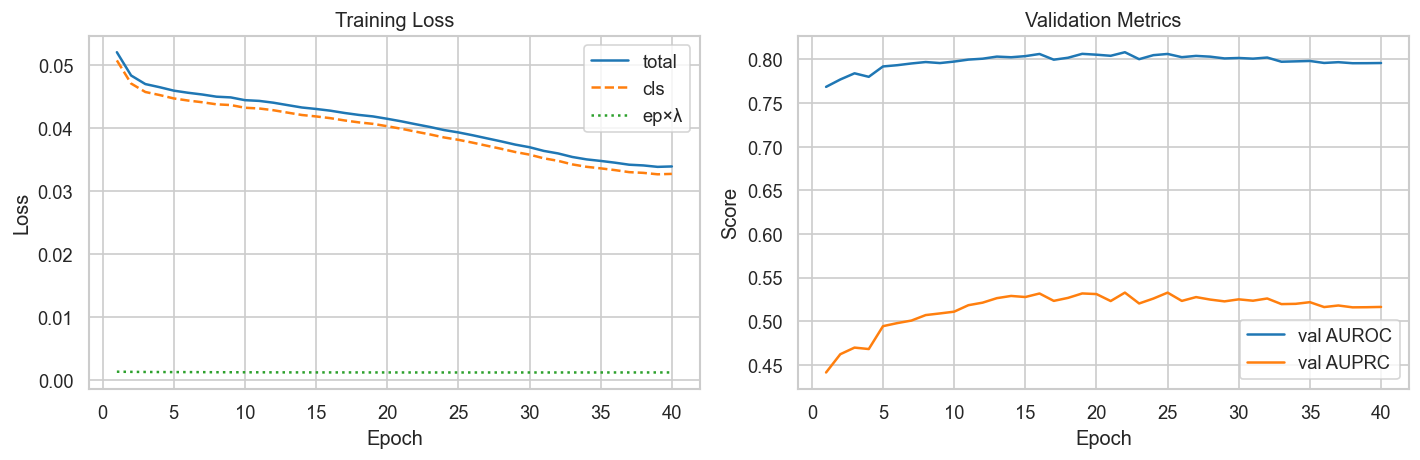

In [7]:
criterion = FocalLoss(alpha=CFG["focal_alpha"], gamma=CFG["focal_gamma"])
opt = AdamW(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])

def lr_at_epoch(epoch):
    if epoch < CFG["warmup_epochs"]:
        return (epoch + 1) / max(1, CFG["warmup_epochs"])
    t = (epoch - CFG["warmup_epochs"]) / max(1, CFG["epochs"] - CFG["warmup_epochs"])
    return 0.5 * (1 + math.cos(math.pi * t))

sched = torch.optim.lr_scheduler.LambdaLR(opt, lr_at_epoch)

@torch.no_grad()
def run_eval(loader):
    model.eval()
    ys, ps = [], []
    ep_list = []
    for x, y in loader:
        x = x.to(device)
        logits, ep, _ = model(x, return_ep=True)
        prob = torch.sigmoid(logits).cpu().numpy()
        ys.append(y.numpy())
        ps.append(prob)
        ep_list.append(ep.cpu().numpy())
    return np.concatenate(ys), np.concatenate(ps), np.concatenate(ep_list, axis=0)

best_auroc = -1.0
best_state = None
history = []

for epoch in range(CFG["epochs"]):
    torch.manual_seed(CFG["random_seed"] + epoch)
    model.train()
    tot = tot_cls = tot_ep = 0.0
    n = 0
    pbar = tqdm(train_loader, desc=f"epoch {epoch+1}/{CFG['epochs']}")
    for x, y in pbar:
        x = x.to(device)
        y = y.to(device).float()
        opt.zero_grad(set_to_none=True)
        logits, ep, v_aux = model(x, return_ep=True)
        L_cls = criterion(logits, y)
        D, a, k_rep = ep[:, 0:1], ep[:, 1:2], ep[:, 2:3]
        L_ep = aliev_panfilov_u_residual(x.detach(), D, a, k_rep, v_aux)
        loss = L_cls + CFG["lambda_ep"] * L_ep
        loss.backward()
        if CFG["grad_clip"]:
            torch.nn.utils.clip_grad_norm_(model.parameters(), CFG["grad_clip"])
        opt.step()
        bs = x.size(0)
        tot += loss.item() * bs
        tot_cls += L_cls.item() * bs
        tot_ep += L_ep.item() * bs
        n += bs
        pbar.set_postfix(loss=f"{tot/n:.4f}", cls=f"{tot_cls/n:.4f}", ep=f"{tot_ep/n:.4f}")
    sched.step()

    vy, vp, _ = run_eval(val_loader)
    val_m = compute_metrics(vy, vp, 0.5)
    history.append({
        "epoch": epoch + 1,
        "train_loss": tot / n,
        "train_cls_loss": tot_cls / n,
        "train_ep_loss": tot_ep / n,
        "val_auroc": val_m.auroc,
        "val_auprc": val_m.auprc,
        "val_cs": val_m.challenge_score,
    })
    logger.info(
        "Epoch %d | train loss %.4f (cls %.4f, ep %.4f) | val AUROC %.4f AUPRC %.4f CS %.4f",
        epoch + 1, tot / n, tot_cls / n, tot_ep / n,
        val_m.auroc, val_m.auprc, val_m.challenge_score,
    )
    if val_m.auroc > best_auroc:
        best_auroc = val_m.auroc
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        torch.save(best_state, "approach7_pinn_best.pt")
        logger.info("  -> New best - checkpoint saved (val AUROC=%.4f)", best_auroc)

if best_state:
    model.load_state_dict(best_state)
    print(f"Restored best val AUROC = {best_auroc:.4f}")

if history:
    df_hist = pd.DataFrame(history)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(df_hist["epoch"], df_hist["train_loss"], label="total")
    axes[0].plot(df_hist["epoch"], df_hist["train_cls_loss"], label="cls", linestyle="--")
    axes[0].plot(df_hist["epoch"], df_hist["train_ep_loss"] * CFG["lambda_ep"], label=f"ep×λ", linestyle=":")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].set_title("Training Loss"); axes[0].legend()
    axes[1].plot(df_hist["epoch"], df_hist["val_auroc"], label="val AUROC")
    axes[1].plot(df_hist["epoch"], df_hist["val_auprc"], label="val AUPRC")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Score")
    axes[1].set_title("Validation Metrics"); axes[1].legend()
    plt.tight_layout()
    plt.show()

---
## 7. Test evaluation & EP feature analysis

Loaded best checkpoint from disk.
Best F1 threshold (val) = 0.505

  Test Results — threshold=0.505 (tuned on val)
  AUROC  : 0.8165  [0.8028 – 0.8295]
  AUPRC  : 0.5361  [0.5050 – 0.5667]
  CS@5%  : 0.2210  [0.2060 – 0.2374]
  F1     : 0.5123  [0.4865 – 0.5346]
  Sens   : 0.5098  [0.4797 – 0.5372]
  Spec   : 0.9039  [0.8967 – 0.9110]



,D_hat,a_hat,b_hat
label,,,
0,0.795357,0.197357,1.041686
1,0.442497,0.141330,0.740972


04:19:59 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
04:19:59 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
04:19:59 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
04:19:59 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
04:19:59 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropria

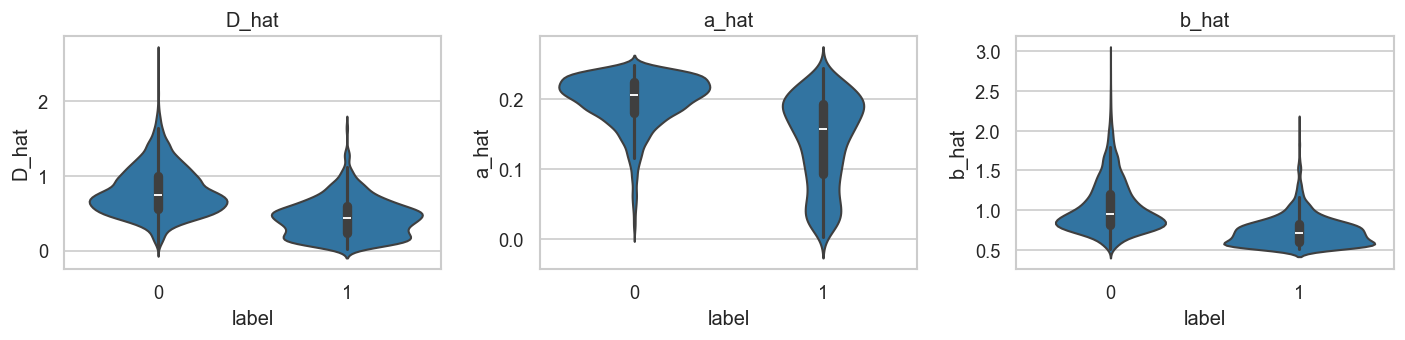

In [8]:
_ckpt = Path("approach7_pinn_best.pt")
if _ckpt.exists():
    model.load_state_dict(torch.load(_ckpt, weights_only=True, map_location=device))
    print("Loaded best checkpoint from disk.")
else:
    raise FileNotFoundError(
        f"Checkpoint '{_ckpt}' not found. Run the training cell (Section 6) before evaluating."
    )

vy, vp, _ = run_eval(val_loader)
best_thr = best_f1_threshold(vy, vp)
print(f"Best F1 threshold (val) = {best_thr:.3f}")

ty, tp, tep = run_eval(test_loader)

def _f1_at(yt, yp):
    return f1_score(yt, (yp >= best_thr).astype(int), zero_division=0)

def _sens_at(yt, yp):
    tn, fp, fn, tp_ = confusion_matrix(yt, (yp >= best_thr).astype(int), labels=[0, 1]).ravel()
    return tp_ / max(1, tp_ + fn)

def _spec_at(yt, yp):
    tn, fp, fn, tp_ = confusion_matrix(yt, (yp >= best_thr).astype(int), labels=[0, 1]).ravel()
    return tn / max(1, tn + fp)

auroc_m, auroc_lo, auroc_hi = bootstrap_ci(ty, tp, roc_auc_score)
auprc_m, auprc_lo, auprc_hi = bootstrap_ci(ty, tp, average_precision_score)
cs_m,    cs_lo,    cs_hi    = bootstrap_ci(ty, tp, calculate_tpr_at_capacity)
f1_m,    f1_lo,    f1_hi    = bootstrap_ci(ty, tp, _f1_at)
sens_m,  sens_lo,  sens_hi  = bootstrap_ci(ty, tp, _sens_at)
spec_m,  spec_lo,  spec_hi  = bootstrap_ci(ty, tp, _spec_at)

print(f"\n{'='*60}")
print(f"  Test Results - threshold={best_thr:.3f} (tuned on val)")
print(f"{'='*60}")
print(f"  AUROC  : {auroc_m:.4f}  [{auroc_lo:.4f} – {auroc_hi:.4f}]")
print(f"  AUPRC  : {auprc_m:.4f}  [{auprc_lo:.4f} – {auprc_hi:.4f}]")
print(f"  CS@5%  : {cs_m:.4f}  [{cs_lo:.4f} – {cs_hi:.4f}]")
print(f"  F1     : {f1_m:.4f}  [{f1_lo:.4f} – {f1_hi:.4f}]")
print(f"  Sens   : {sens_m:.4f}  [{sens_lo:.4f} – {sens_hi:.4f}]")
print(f"  Spec   : {spec_m:.4f}  [{spec_lo:.4f} – {spec_hi:.4f}]")
print(f"{'='*60}\n")

df_ep = pd.DataFrame(tep, columns=["D_hat", "a_hat", "b_hat"])
df_ep["label"] = ty
display(df_ep.groupby("label").mean())

fig, ax = plt.subplots(1, 3, figsize=(12, 3))
for i, c in enumerate(["D_hat", "a_hat", "b_hat"]):
    sns.violinplot(data=df_ep, x="label", y=c, ax=ax[i])
    ax[i].set_title(c)
plt.tight_layout()
plt.show()

In [9]:
print("Mann–Whitney U tests on EP features:")
print(f"{'Feature':<10}  {'Chagas− mean':>14}  {'Chagas+ mean':>14}  {'p-value':>12}  sig")
print("-" * 62)
for col in ["D_hat", "a_hat", "b_hat"]:
    neg = df_ep.loc[df_ep["label"] == 0, col].values
    pos = df_ep.loc[df_ep["label"] == 1, col].values
    _, p = mannwhitneyu(neg, pos, alternative="two-sided")
    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
    print(f"{col:<10}  {neg.mean():>14.4f}  {pos.mean():>14.4f}  {p:>12.2e}  {sig}")

print("""
Clinical interpretation:
  D_hat (conduction proxy): Chagas disease causes fibrosis and conduction system
  damage (RBBB, fascicular blocks, QRS prolongation). Lower D_hat in Chagas+
  patients is consistent with reduced conduction velocity.

  a_hat (excitability threshold): Chagas-related scarring raises the depolarisation
  threshold in affected tissue; higher a_hat in Chagas+ aligns with reduced excitability.

  b_hat / k_rep (repolarisation scale): Altered APD in Chagas cardiomyopathy may
  manifest as QTc prolongation; differences in b_hat reflect repolarisation heterogeneity.

Reminder: learned values are discriminative biomarkers, not direct AP model estimates.
""")

Mann–Whitney U tests on EP features:
Feature       Chagas− mean    Chagas+ mean       p-value  sig
--------------------------------------------------------------
D_hat               0.7954          0.4425      0.00e+00  ***
a_hat               0.1974          0.1413      0.00e+00  ***
b_hat               1.0417          0.7410      0.00e+00  ***

Clinical interpretation:
  D_hat (conduction proxy): Chagas disease causes fibrosis and conduction system
  damage (RBBB, fascicular blocks, QRS prolongation). Lower D_hat in Chagas+
  patients is consistent with reduced conduction velocity.

  a_hat (excitability threshold): Chagas-related scarring raises the depolarisation
  threshold in affected tissue; higher a_hat in Chagas+ aligns with reduced excitability.

  b_hat / k_rep (repolarisation scale): Altered APD in Chagas cardiomyopathy may
  manifest as QTc prolongation; differences in b_hat reflect repolarisation heterogeneity.

Reminder: learned values are discriminative biomarkers, not 

In [10]:

torch.manual_seed(CFG["random_seed"])
model_abl = EPPINNChagas(CFG).to(device)
opt_abl = AdamW(model_abl.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])
sched_abl = torch.optim.lr_scheduler.LambdaLR(opt_abl, lr_at_epoch)
best_auroc_abl = -1.0

for epoch in range(CFG["epochs"]):
    torch.manual_seed(CFG["random_seed"] + epoch)
    model_abl.train()
    tot_abl = n_abl = 0
    for x, y in tqdm(train_loader, desc=f"ablation {epoch+1}/{CFG['epochs']}"):
        x, y = x.to(device), y.to(device).float()
        opt_abl.zero_grad(set_to_none=True)
        loss = criterion(model_abl(x), y)
        loss.backward()
        if CFG["grad_clip"]:
            torch.nn.utils.clip_grad_norm_(model_abl.parameters(), CFG["grad_clip"])
        opt_abl.step()
        tot_abl += loss.item() * x.size(0)
        n_abl += x.size(0)
    sched_abl.step()

    model_abl.eval()
    ys_a, ps_a = [], []
    with torch.no_grad():
        for x, y in val_loader:
            ps_a.append(torch.sigmoid(model_abl(x.to(device))).cpu().numpy())
            ys_a.append(y.numpy())
    auroc_a = roc_auc_score(np.concatenate(ys_a), np.concatenate(ps_a))
    logger.info("Ablation epoch %d | train loss %.4f | val AUROC %.4f", epoch + 1, tot_abl / n_abl, auroc_a)
    if auroc_a > best_auroc_abl:
        best_auroc_abl = auroc_a
        torch.save({k: v.cpu().clone() for k, v in model_abl.state_dict().items()}, "approach7_pinn_ablation_best.pt")

if "best_auroc" not in globals():
    print("WARNING: best_auroc not found - run Section 6 before comparing. Showing ablation result only.")
    _main_auroc = float("nan")
else:
    _main_auroc = best_auroc

print(f"\n{'='*50}")
print(f"  Ablation comparison (best val AUROC)")
print(f"{'='*50}")
print(f"  With physics loss  (λ={CFG['lambda_ep']}):  {_main_auroc:.4f}")
print(f"  Without physics loss (λ=0):    {best_auroc_abl:.4f}")
print(f"  Delta (physics contribution):  {_main_auroc - best_auroc_abl:+.4f}")
print(f"{'='*50}")

ablation 1/40: 100%|██████████| 2150/2150 [02:43<00:00, 13.14it/s]
04:22:57 [INFO] Ablation epoch 1 | train loss 0.0506 | val AUROC 0.7688
ablation 2/40: 100%|██████████| 2150/2150 [02:45<00:00, 13.03it/s]
04:25:56 [INFO] Ablation epoch 2 | train loss 0.0468 | val AUROC 0.7794
ablation 3/40: 100%|██████████| 2150/2150 [02:45<00:00, 13.02it/s]
04:28:55 [INFO] Ablation epoch 3 | train loss 0.0456 | val AUROC 0.7856
ablation 4/40: 100%|██████████| 2150/2150 [02:45<00:00, 12.98it/s]
04:31:55 [INFO] Ablation epoch 4 | train loss 0.0451 | val AUROC 0.7887
ablation 5/40: 100%|██████████| 2150/2150 [02:45<00:00, 12.98it/s]
04:34:56 [INFO] Ablation epoch 5 | train loss 0.0446 | val AUROC 0.7931
ablation 6/40: 100%|██████████| 2150/2150 [02:45<00:00, 12.98it/s]
04:37:56 [INFO] Ablation epoch 6 | train loss 0.0442 | val AUROC 0.7948
ablation 7/40: 100%|██████████| 2150/2150 [02:46<00:00, 12.95it/s]
04:40:57 [INFO] Ablation epoch 7 | train loss 0.0440 | val AUROC 0.7989
ablation 8/40: 100%|███████


  Ablation comparison (best val AUROC)
  With physics loss  (λ=0.05):  0.8083
  Without physics loss (λ=0):    0.8096
  Delta (physics contribution):  -0.0012


### Logistic regression on frozen EP features

Fit a logistic regression on (D_hat, a_hat, b_hat) extracted with the encoder in eval mode. Sanity check for how separable the three features are on their own.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

model.eval()

@torch.no_grad()
def collect_ep(indices):
    ds = CachedChagasDataset(cache_file, indices)
    ld = DataLoader(ds, batch_size=64, shuffle=False)
    ep_l, y_l = [], []
    for x, y in ld:
        x = x.to(device)
        _, ep, _ = model(x, return_ep=True)
        ep_l.append(ep.cpu().numpy())
        y_l.append(y.numpy())
    return np.concatenate(ep_l), np.concatenate(y_l)

X_tr, y_tr = collect_ep(train_indices)
X_va, y_va = collect_ep(val_indices)
X_te, y_te = collect_ep(test_indices)

sc = StandardScaler().fit(X_tr)
lr_clf = LogisticRegression(max_iter=200, class_weight="balanced")
lr_clf.fit(sc.transform(X_tr), y_tr)

p_va = lr_clf.predict_proba(sc.transform(X_va))[:, 1]
lr_thr = best_f1_threshold(y_va, p_va)
m_lr_va = compute_metrics(y_va, p_va, lr_thr)
print(f"LogReg on EP features (val)  | AUROC={m_lr_va.auroc:.4f} AUPRC={m_lr_va.auprc:.4f} CS={m_lr_va.challenge_score:.4f}")

p_te = lr_clf.predict_proba(sc.transform(X_te))[:, 1]
m_lr_te = compute_metrics(y_te, p_te, lr_thr)
print(f"LogReg on EP features (test) | AUROC={m_lr_te.auroc:.4f} AUPRC={m_lr_te.auprc:.4f} CS={m_lr_te.challenge_score:.4f}")

LogReg on EP features (val)  | AUROC=0.8064 AUPRC=0.5313 CS=0.2295
LogReg on EP features (test) | AUROC=0.8147 AUPRC=0.5339 CS=0.2213
